In [ ]:
import numpy as np
import torch
from transformers.modeling_rope_utils import ROPE_INIT_FUNCTIONS, dynamic_rope_update

In [ ]:
img = torch.randn(1, 3, 32, 32)
H, W = 32, 32
h_pos = torch.arange(H).view(H, 1).repeat(1, W).flatten()
w_pos = torch.arange(W).view(1, W).repeat(H, 1).flatten()
img_grid_hw = torch.stack([h_pos, w_pos], dim=0)  # (2, H*W)
img_grid_hw
img_grid_hw.flatten()

# input_ids: [bs, seq_len]

tensor([ 0,  0,  0,  ..., 29, 30, 31])

In [ ]:
img_grid_hw_t = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")
img_grid_hw_t = torch.stack(img_grid_hw_t, dim=0).view(2, -1)  # (2, H*W)
img_grid_hw_t  # [HHHHWWWW]

tensor([[ 0,  0,  0,  ..., 31, 31, 31],
        [ 0,  1,  2,  ..., 29, 30, 31]])

In [ ]:
dim = 128 * 16
dim_h = 128
rope_inv_freq = 1.0 / (10000 ** (torch.arange(0, dim_h, 2).float() / dim_h))
rope_init_func = ROPE_INIT_FUNCTIONS["linear"]
max_position_embeddings = 1024
# rope_inv_freq
print(rope_inv_freq.shape)

torch.Size([64])


In [ ]:
from easydict import EasyDict

rope_cfg = {
    "rope_parameters": dict(
        rope_theta=100.0,
        max_position_embeddings=max_position_embeddings,
        original_max_position_embeddings=1024,
        factor=1.0,
    ),
    "hidden_size": 128 * 16 / 2,  # because 2D
    "num_attention_heads": 16,
}
rope_cfg = EasyDict(rope_cfg)
inv_freq, _ = rope_init_func(rope_cfg, "cuda")  # [dim_h/2]
print(inv_freq.shape)

torch.Size([32])


In [ ]:
inv_freq  # [dim_h/2]
img_grid_hw.flatten()  # [hw*2]

pos_ids  #  [bs, s]
inv_freq_expanded = inv_freq[None, :, None].expand(
    pos_ids.shape[0], -1, 1
)  # [bs, dim_h/2, 1]
pos_ids_expanded = pos_ids[:, None, :]  # [bs, 1, s]

freqs = (
    inv_freq_expanded @ pos_ids_expanded
)  # [bs, dim_h/2, s] @ [bs, 1, s] -> [bs, dim_h/2, s]
freqs = freqs.transpose(1, 2)  # [bs, s, dim_h/2]
emb = torch.cat([freqs, freqs], dim=-1)  # [bs, s, dim_h]
cos = emb.cos()
sin = emb.sin()

In [ ]:
img_pos_ids = img_grid_hw.cuda()  # [2*hw]
freqs = torch.einsum("in,d->ind", img_pos_ids, inv_freq)  # [2, hw, dim_h/2]
print(freqs.shape)
assert freqs.shape[1] == H * W
i_chans = freqs.shape[-1] // 2

# Selection
freqs_sel = []
for i, m in enumerate(freqs.chunk(2, dim=-1)):
    freqs_sub = m[i % 2]
    freqs_sel.append(freqs_sub)
freqs_sel = torch.cat(freqs_sel, dim=-1)
print("selection freqs dim: ", freqs_sel.shape)

emb_sel = torch.cat([freqs_sel, freqs_sel], dim=-1)  # [hw, dim_h]
cos_sel = emb_sel.cos()
sin_sel = emb_sel.sin()


# Interleaving: MRoPE_i from qwen3vl
freqs_final = freqs[0]  # [hw, dim_h/2]
mrope_sects = [16, 16]
L = mrope_sects[1] * 2
# HWHWHWHW
idx = slice(1, L, 2)
print(idx)
freqs_final[..., idx] = freqs[1][..., idx]
print("interleaving freqs dim: ", freqs_final.shape)

emb_final = torch.cat([freqs_final, freqs_final], dim=-1)  # [hw, dim_h]
cos_final = emb_final.cos()
sin_final = emb_final.sin()

torch.Size([2, 1024, 32])
selection freqs dim:  torch.Size([1024, 32])
slice(1, 32, 2)
interleaving freqs dim:  torch.Size([1024, 32])


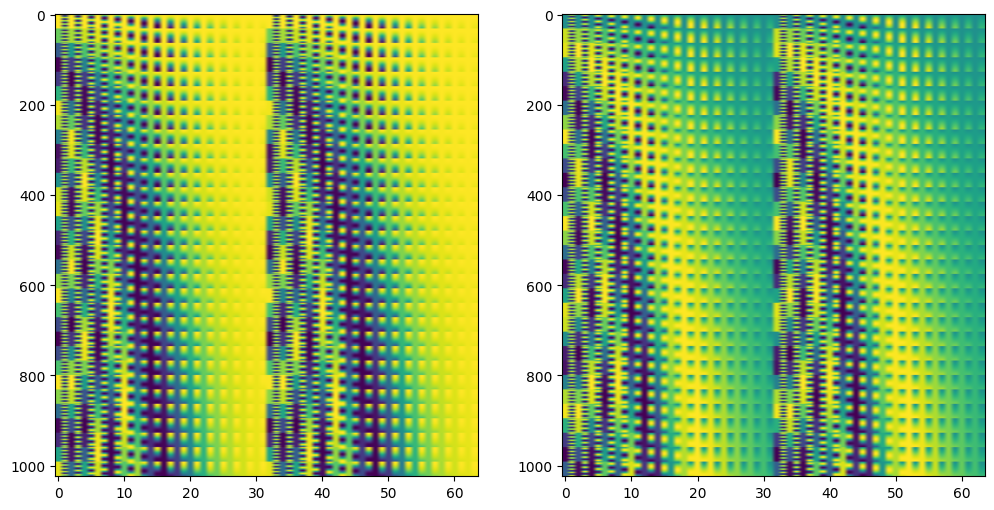

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cos_final.cpu().numpy(), aspect="auto")
plt.subplot(1, 2, 2)
plt.imshow(sin_final.cpu().numpy(), aspect="auto")

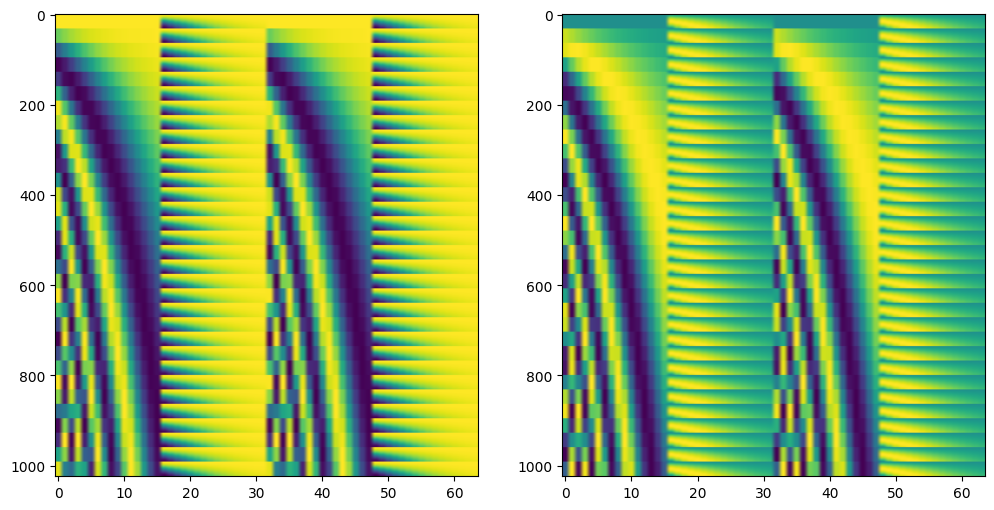

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cos_sel.cpu().numpy(), aspect="auto")
plt.subplot(1, 2, 2)
plt.imshow(sin_sel.cpu().numpy(), aspect="auto")

torch.Size([1024, 64])


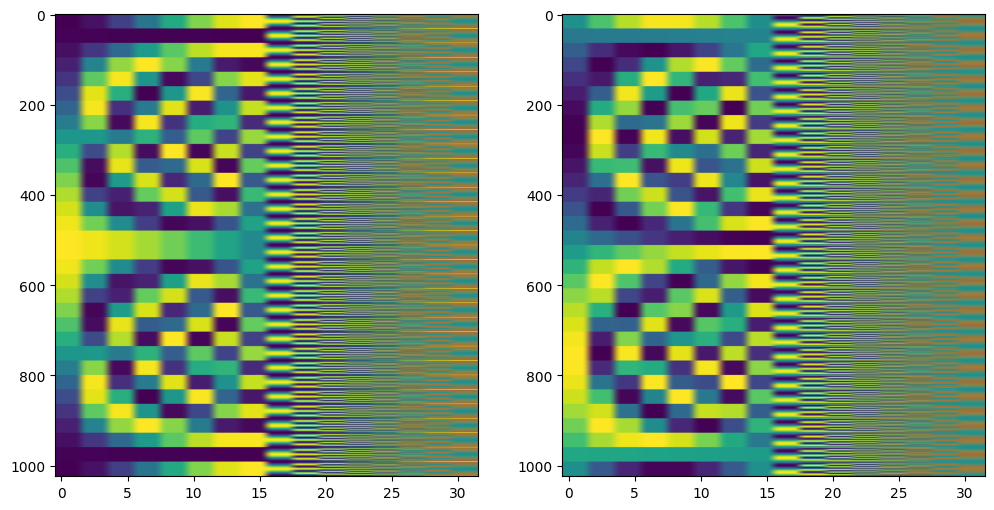

In [24]:
from timm.layers import RotaryEmbeddingCat, create_rope_embed

# rope = RotaryEmbeddingCat(dim=32, in_pixels=False, max_res=32, temperature=10000.0)
rope = RotaryEmbeddingCat(
    dim=32, in_pixels=True, max_res=32, temperature=10.0, linear_bands=True
)
rope_emb_timm = rope.get_embed((32, 32))
print(rope_emb_timm.shape)
sin_timm, cos_timm = rope_emb_timm.chunk(2, dim=-1)

# plt
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cos_timm.cpu().numpy(), aspect="auto")
plt.subplot(1, 2, 2)
plt.imshow(sin_timm.cpu().numpy(), aspect="auto")

torch.Size([1024, 64])


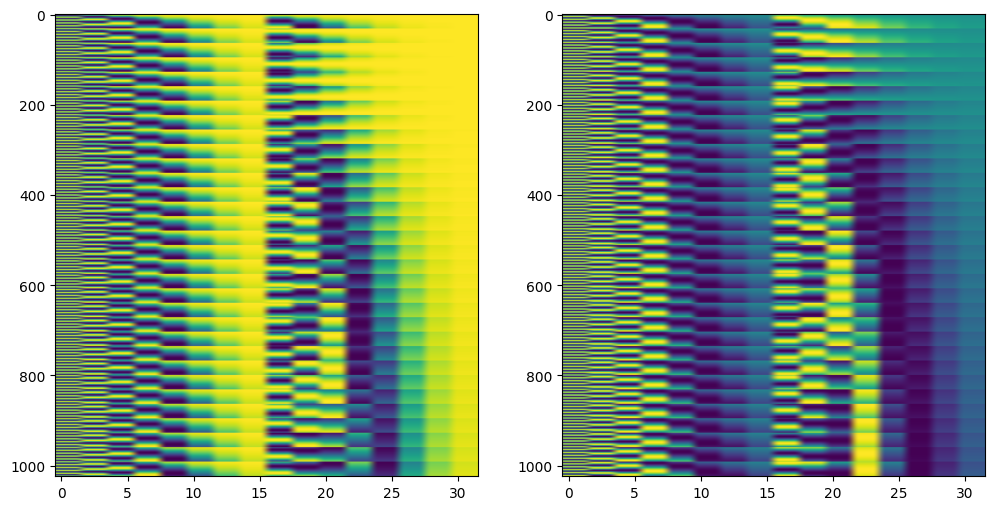

In [ ]:
from timm.layers import RotaryEmbeddingMixed

rope = RotaryEmbeddingMixed(dim=32, depth=1, num_heads=1, temperature=100.0)
rope_emb_timm = rope.get_embed((32, 32))[0].detach()[0]
print(rope_emb_timm.shape)
sin_timm, cos_timm = rope_emb_timm.chunk(2, dim=-1)

# plt
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cos_timm.cpu().numpy(), aspect="auto")
plt.subplot(1, 2, 2)
plt.imshow(sin_timm.cpu().numpy(), aspect="auto")

torch.Size([1024, 64])


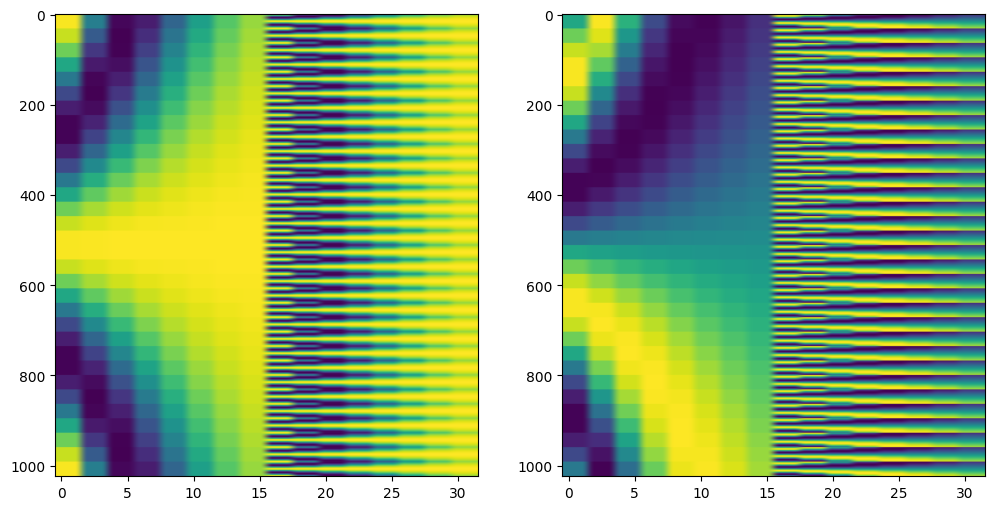

In [ ]:
from timm.layers import RotaryEmbeddingDinoV3

rope = RotaryEmbeddingDinoV3(dim=32, temperature=10.0, rotate_half=False)
rope_emb_timm = rope.get_embed((32, 32))
print(rope_emb_timm.shape)
sin_timm, cos_timm = rope_emb_timm.chunk(2, dim=-1)

# plt
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cos_timm.cpu().numpy(), aspect="auto")
plt.subplot(1, 2, 2)
plt.imshow(sin_timm.cpu().numpy(), aspect="auto")

In [ ]:
import sys

sys.path.append("/home/user/zihancao/Project/hyperspectral-1d-tokenizer")

from src.stage1.cosmos.modules.rope import RotaryPositionEmbeddingPytorchV2
from src.stage1.cosmos.modules.ropev2 import RotaryEmbedding

04:40:00 - 🔍 [DEBUG ] blocks.py:68 - will compile the forward function and disable donated buffer
04:40:00 - 🔍 [DEBUG ] norm.py:177 - [Timm registered new acts]: 'swiglu', 'poly_norm'
04:40:00 - 🔍 [DEBUG ] norm.py:197 - [Timm registered FLA acts]: fla_swish, fla_silu, fla_fast_gelu, fla_swiglu
04:40:00 - 🔍 [DEBUG ] norm.py:255 - [Timm registered new norms]: 'zeromeanrmsnorm', 'flashrmsnorm', 'tritonrmsnorm2d'
04:40:09 - 🔍 [DEBUG ] mlp.py:44 - [Mlp Fused Kernels]: XFORMERS_AVAILABLE: True, FLA_AVAILABLE: True


torch.Size([1, 1024, 1, 32]) torch.Size([1, 1024, 1, 32])


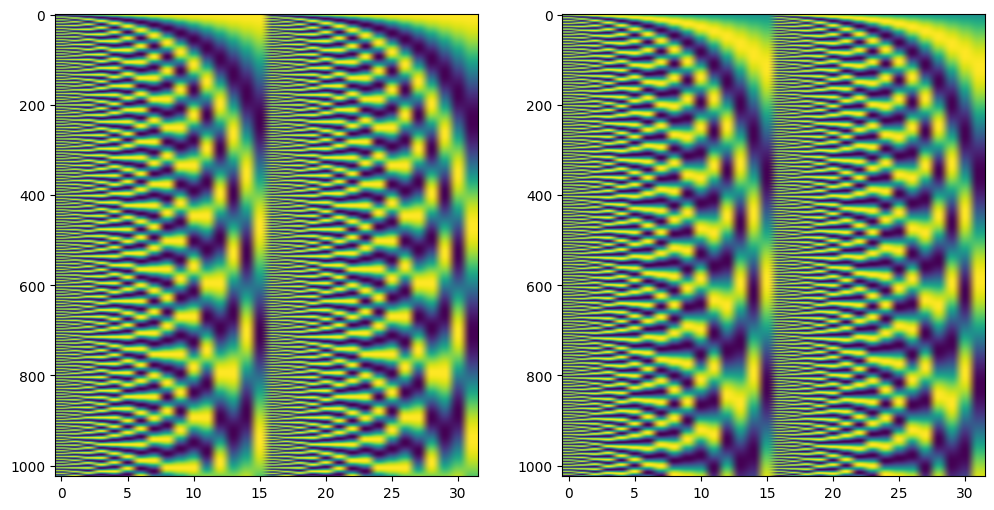

In [ ]:
rope = RotaryPositionEmbeddingPytorchV2(
    seq_len=32 * 32, dim=32, rope_theta=100.0, max_position_embeddings=32 * 32
)
emb_cos_rotary, emb_sin_rotary = rope.cos_cached, rope.sin_cached
print(emb_cos_rotary.shape, emb_sin_rotary.shape)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(emb_cos_rotary.squeeze().cpu().numpy(), aspect="auto")
plt.subplot(1, 2, 2)
plt.imshow(emb_sin_rotary.squeeze().cpu().numpy(), aspect="auto")

torch.Size([1, 1024, 32])


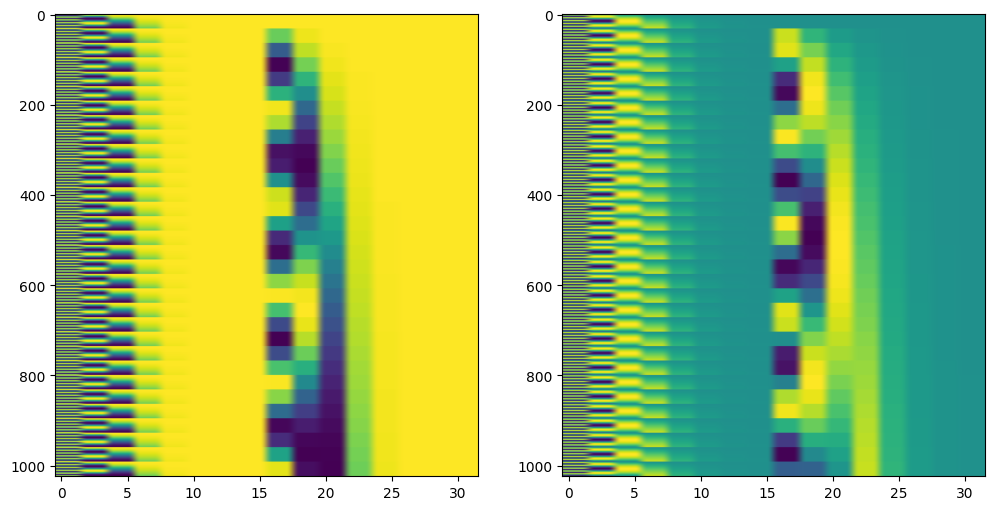

In [ ]:
import sys

sys.path.append(
    "/home/user/zihancao/Project/hyperspectral-1d-tokenizer/src/stage1/perception_models/core/vision_encoder"
)

from rope import Rope2D, RotaryEmbedding

rope = Rope2D(32, False)
rope.init_tensors()
rope.update_grid("cuda", 32, 32)
freqs = rope.freq
print(freqs.shape)
freqs = freqs[0]

cos_emb = torch.cos(freqs)
sin_emb = torch.sin(freqs)


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cos_emb.cpu().numpy(), aspect="auto")
plt.subplot(1, 2, 2)
plt.imshow(sin_emb.cpu().numpy(), aspect="auto")

torch.Size([1024, 32])


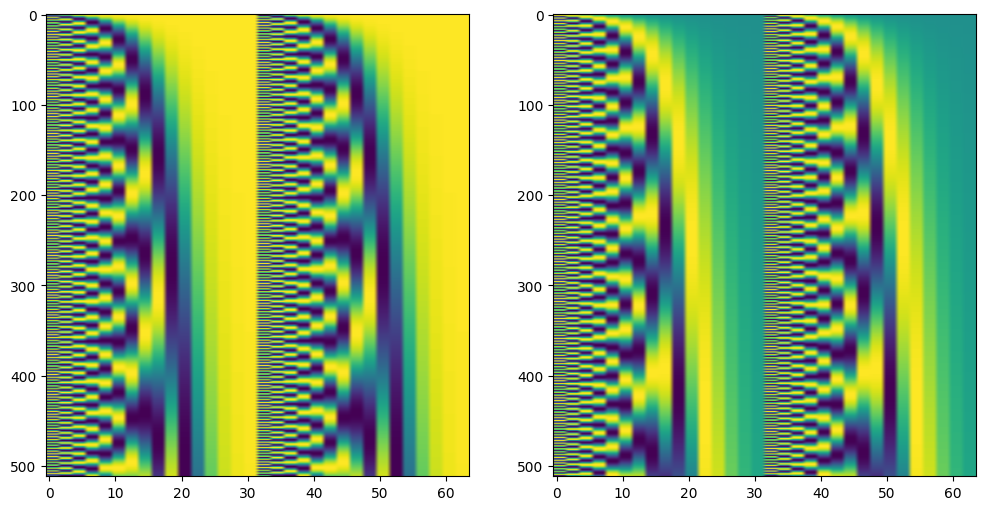

: 

In [ ]:
# rope = RotaryEmbedding(max_freq=100, dim=32, freqs_for="pixel")
rope = RotaryEmbedding(theta=10000, dim=32, freqs_for="lang")
freqs = rope.get_axial_freqs(32 * 32)
print(freqs.shape)

# plot out
freqs = freqs.view(-1, 64)
cos_emb = freqs.cos()
sin_emb = freqs.sin()
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cos_emb.cpu().numpy(), aspect="auto")
plt.subplot(1, 2, 2)
plt.imshow(sin_emb.cpu().numpy(), aspect="auto")